# NeuralTuner TRL Training Notebook

This notebook is for training and evaluation only. Inference-only logic lives in `inference.py`.

Model default: `Qwen/Qwen2.5-0.5B-Instruct`


In [11]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import os
import torch
import gc
import wandb
import trl.extras.profiling as trl_profiling

from server.neural_tuner_env_environment import NeuralTunerEnvironment
from scripts.neural_tuner import NeuralTunerOpenEnv
from scripts.training_utils import collect_rewards_with_autosubmit, split_scenarios
from models import NeuralTunerAction
from rollout_eval import run_random_episode, run_baseline_episode, run_heuristic_episode
import statistics
from huggingface_hub import snapshot_download

from dataclasses import asdict
from datasets import Dataset
from peft import LoraConfig
from transformers import AutoTokenizer
from collections import Counter
from trl import GRPOConfig, GRPOTrainer, SFTConfig, SFTTrainer
from trl.chat_template_utils import qwen3_chat_template, qwen3_schema

In [ ]:
# os.environ["HF_TOKEN"] = ""
# os.environ["WANDB_API_KEY"] = ""
# os.environ["WANDB_PROJECT"] = "neural_tuner_grpo"
print("HF_TOKEN loaded:", bool(os.getenv("HF_TOKEN")))
print("WANDB_API_KEY loaded:", bool(os.getenv("WANDB_API_KEY")))

HF_TOKEN = os.getenv("HF_TOKEN")
WANDB_API_KEY = os.getenv("WANDB_API_KEY")
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "neural_tuner_grpo")

# TRL profiling expects a module-level `wandb` symbol.
trl_profiling.wandb = wandb

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
    wandb.init(
        project=WANDB_PROJECT,
        name=f"neural_tuner_grpo",
        resume="never",
        reinit="finish_previous",
    )

HF_TOKEN loaded: True
WANDB_API_KEY loaded: False


In [13]:
# --- Model switch (change ONE line) ---
# Options: "0.5B" or "1.5B"
MODEL_FLAVOR = "0.5B"

MODEL_REGISTRY = {
    "0.5B": {
        "repo_id": "Qwen/Qwen2.5-0.5B-Instruct",
        "cache_dir": ".hf_cache/Qwen--Qwen2.5-0.5B-Instruct",
    },
    "1.5B": {
        "repo_id": "Qwen/Qwen2.5-1.5B-Instruct",
        "cache_dir": ".hf_cache/Qwen--Qwen2.5-1.5B-Instruct",
    },
}
if MODEL_FLAVOR not in MODEL_REGISTRY:
    raise ValueError(f"Unsupported MODEL_FLAVOR={MODEL_FLAVOR}. Use one of: {list(MODEL_REGISTRY)}")

MODEL_REPO_ID = MODEL_REGISTRY[MODEL_FLAVOR]["repo_id"]
LOCAL_MODEL_DIR = Path(MODEL_REGISTRY[MODEL_FLAVOR]["cache_dir"]).resolve()
LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = "outputs/neural_tuner_grpo_tiny_lora"
DEBUG_STEP_LOG_PATH = Path(OUTPUT_DIR) / "step_io_debug.txt"
_DEBUG_STEP_COUNTER = 0
DEBUG_STEP_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
DEBUG_STEP_LOG_PATH.write_text("", encoding="utf-8")

TARGET_LOCAL_MODEL_DIR = LOCAL_MODEL_DIR
MODEL_NAME = str(TARGET_LOCAL_MODEL_DIR)
TRAIN_EPISODES = 80
NUM_EPOCHS = 1
NUM_STEPS = 5
SFT_WARMUP_STEPS = 20
MOCK_DATA_PATH = Path("data/mock_data/neural_tuner_train_scenarios.jsonl")
TRAIN_FRACTION = 0.95
SPLIT_SEED = 42


SYSTEM_PROMPT = """You are a hardware optimization agent for NeuralTuner.
Use available tools to profile layers, apply quantization and pruning, benchmark, and submit.
Prioritize meeting latency, memory, and accuracy constraints while maximizing reward.

Critical rules:
- Only use layer IDs that appear in the current LAYERS table.
- Invalid layer IDs are penalized.
- Do at least one benchmark before submit when possible.

Example tool-call sequence (format to follow):
<tool_call>{"name": "profile_layer", "arguments": {"layer_id": "layer1"}}</tool_call>
<tool_call>{"name": "quantize_layer", "arguments": {"layer_id": "layer1", "dtype": "INT8"}}</tool_call>
<tool_call>{"name": "benchmark", "arguments": {}}</tool_call>
<tool_call>{"name": "submit", "arguments": {}}</tool_call>
"""

##### Helpers

In [14]:
def print_pre_training_stats(random_mean, random_std, random_rewards, oracle):
    print(f"Pre-training (random policy, n=20):  mean={random_mean:.4f}  std={random_std:.4f}  min={min(random_rewards):.4f}  max={max(random_rewards):.4f}")
    print(f"Oracle ceiling (INT4/INT8 pattern):   reward={oracle.final_reward:.4f}  constraints_met={oracle.constraints_met}")
    print(f"Improvement headroom: {oracle.final_reward - random_mean:.4f} ({(oracle.final_reward/random_mean - 1)*100:.1f}% above random)")
    print(f"GRPO target: bring random {random_mean:.3f} closer to {oracle.final_reward:.3f}")


def plot_pre_training_reward_distribution(random_rewards, random_mean, oracle):
    _, ax = plt.subplots(figsize=(7, 4))
    ax.hist(random_rewards, bins=10, color="steelblue", alpha=0.7, label="Random policy (n=20)")
    ax.axvline(random_mean, color="steelblue", linestyle="--", lw=2, label=f"Random mean={random_mean:.3f}")
    ax.axvline(oracle.final_reward, color="darkorange", linestyle="--", lw=2, label=f"Oracle ceiling={oracle.final_reward:.3f}")
    ax.set_xlabel("Episode Reward")
    ax.set_ylabel("Count")
    ax.set_title("NeuralTuner: Pre-Training Reward Distribution (inception_v3 medium)")
    ax.legend()
    plt.tight_layout()
    plot_dir = Path("artifacts/plots")
    plot_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_dir / "pre_training_reward_distribution.png", dpi=150)
    plt.show()
    print(f"Saved: artifacts/plots/pre_training_reward_distribution.png")


def _has_local_model_tensors(model_dir: Path) -> bool:
    has_config = (model_dir / "config.json").exists()
    has_tokenizer = (model_dir / "tokenizer.json").exists() or (model_dir / "tokenizer_config.json").exists()
    has_weights = any(model_dir.glob("*.safetensors")) or any(model_dir.glob("*.bin"))
    return has_config and has_tokenizer and has_weights


def get_runtime_device() -> str:
    """Select best available device: CUDA -> MPS -> CPU."""
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"


RUNTIME_DEVICE = get_runtime_device()
USE_CPU = RUNTIME_DEVICE == "cpu"

In [15]:

def _format_role_text(message_obj) -> str:
    if isinstance(message_obj, dict):
        role = message_obj.get("role", "unknown")
        content = message_obj.get("content", "")
        return f"[{role}] {content}"
    return str(message_obj)


def _append_step_io_debug(
    prompts,
    completions,
    rewards,
    std,
    step_hint=None,
    advantages=None,
    component_rows=None,
) -> None:
    global _DEBUG_STEP_COUNTER
    _DEBUG_STEP_COUNTER += 1
    DEBUG_STEP_LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

    step_label = step_hint if step_hint is not None else _DEBUG_STEP_COUNTER
    lines = [
        f"\n=== STEP {step_label} (reward_call={_DEBUG_STEP_COUNTER}) ===",
        f"reward_list={rewards}",
        f"reward_std={std:.6f}",
    ]

    if advantages is not None:
        lines.append(f"advantages={advantages}")
    if component_rows is not None:
        lines.append(f"reward_components={component_rows}")

    num_rows = max(len(prompts), len(completions)) if prompts or completions else 0
    for i in range(num_rows):
        prompt = prompts[i] if i < len(prompts) else None
        completion = completions[i] if i < len(completions) else None

        prompt_text = ""
        if isinstance(prompt, list):
            prompt_text = "\n".join(_format_role_text(x) for x in prompt)
        elif prompt is not None:
            prompt_text = _format_role_text(prompt)

        completion_text = ""
        if isinstance(completion, list):
            completion_text = "\n".join(_format_role_text(x) for x in completion)
        elif completion is not None:
            completion_text = _format_role_text(completion)

        lines.extend(
            [
                f"-- sample {i} input --",
                prompt_text,
                f"-- sample {i} output --",
                completion_text,
            ]
        )

    payload = "\n".join(lines) + "\n"
    with DEBUG_STEP_LOG_PATH.open("a", encoding="utf-8") as fp:
        fp.write(payload)


def reward_func(environments, **kwargs) -> list[float]:
    base_rewards = collect_rewards_with_autosubmit(environments)
    prompts = kwargs.get("prompts") or []
    completions = kwargs.get("completions") or []

    shaped_rewards = []
    component_rows = []
    for i, (env, base_reward) in enumerate(zip(environments, base_rewards)):
        benchmark_delta = 0.0
        action_quality = 0.0
        if hasattr(env, "_consume_reward_components"):
            components = env._consume_reward_components() or {}
            benchmark_delta = float(components.get("benchmark_delta_reward", 0.0))
            action_quality = float(components.get("action_quality_reward", 0.0))

        # Conservative shaping: keep submit reward dominant.
        intermediate_total = 0.5 * benchmark_delta + 0.5 * action_quality

        completion_text = ""
        if i < len(completions):
            completion_obj = completions[i]
            if isinstance(completion_obj, list):
                completion_text = "\n".join(_format_role_text(x) for x in completion_obj)
            else:
                completion_text = _format_role_text(completion_obj)

        # Anti-collapse penalties
        if "<tool_call>" not in completion_text:
            intermediate_total -= 0.03
        if "benchmark" not in completion_text:
            intermediate_total -= 0.01

        capped_intermediate = max(-0.05, min(0.05, intermediate_total))
        final_reward = max(0.0, min(1.0, float(base_reward) + capped_intermediate))
        shaped_rewards.append(final_reward)

        component_rows.append(
            {
                "base_submit_reward": round(float(base_reward), 6),
                "benchmark_delta_reward": round(benchmark_delta, 6),
                "action_quality_reward": round(action_quality, 6),
                "collapse_penalty": round(capped_intermediate - (0.5 * benchmark_delta + 0.5 * action_quality), 6),
                "final_shaped_reward": round(final_reward, 6),
            }
        )

    std = statistics.stdev(shaped_rewards) if len(shaped_rewards) > 1 else 0.0

    step_hint = kwargs.get("global_step")
    trainer_state = kwargs.get("trainer_state")
    if step_hint is None and trainer_state is not None:
        step_hint = getattr(trainer_state, "global_step", None)

    advantages = kwargs.get("advantages")
    _append_step_io_debug(
        prompts,
        completions,
        shaped_rewards,
        std,
        step_hint=step_hint,
        advantages=advantages,
        component_rows=component_rows,
    )

    return shaped_rewards


def _load_mock_scenarios(path: Path) -> list[dict]:
    if not path.exists():
        raise FileNotFoundError(f"Mock training data not found: {path}")
    rows = []
    with path.open() as fp:
        for line in fp:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    if not rows:
        raise ValueError(f"No scenarios found in {path}")
    return rows


def _build_prompt_row(scenario: dict) -> list[dict]:
    scenario_text = (
        f"Scenario ID: {scenario['id']}\n"
        f"Model: {scenario['model_id']}\n"
        f"Difficulty: {scenario['difficulty']}\n"
        f"Hint: {scenario['scenario_hint']}\n"
        f"Target behavior: {scenario['target_behavior']}\n"
        f"Notes: {scenario['notes']}\n"
    )
    return [{"role": "user", "content": SYSTEM_PROMPT + "\n\n" + scenario_text}]


def _layer_ids_from_text(text: str) -> list[str]:
    """Extract layer IDs from environment reset observation text."""
    ids = []
    for line in text.splitlines():
        s = line.strip()
        if not s or s.startswith("ACTIONS") or s.startswith("Tip:"):
            break
        if s.startswith("Layer ID") or s.startswith("-"):
            continue
        if "HIDDEN" in s:
            ids.append(s.split()[0])
    return ids


def _build_sft_dataset(scenarios: list[dict]) -> Dataset:
    """Run the heuristic policy on each scenario and capture tool-call sequences as SFT labels."""
    _sft_env = NeuralTunerEnvironment()
    records = []
    for scenario in scenarios:
        reset_obs = _sft_env.reset(model_id=scenario["model_id"], difficulty=scenario["difficulty"])
        layer_ids = _layer_ids_from_text(reset_obs.output)

        tool_calls = []
        profiled: dict[str, float] = {}

        for layer_id in layer_ids[:6]:
            tool_calls.append(
                f'<tool_call>{{"name": "profile_layer", "arguments": {{"layer_id": "{layer_id}"}}}}</tool_call>'
            )
            obs = _sft_env.step(NeuralTunerAction(action_type="profile_layer", layer_id=layer_id))
            sensitivity = float((obs.metadata or {}).get("sensitivity", 1.0))
            profiled[layer_id] = sensitivity

        for layer_id, sensitivity in profiled.items():
            dtype = "INT4" if sensitivity < 0.10 else "INT8" if sensitivity < 0.20 else "FP16" if sensitivity < 0.30 else "FP32"
            tool_calls.append(
                f'<tool_call>{{"name": "quantize_layer", "arguments": {{"layer_id": "{layer_id}", "dtype": "{dtype}"}}}}</tool_call>'
            )
            _sft_env.step(NeuralTunerAction(action_type="quantize_layer", layer_id=layer_id, dtype=dtype))

        tool_calls.append('<tool_call>{"name": "benchmark", "arguments": {}}</tool_call>')
        _sft_env.step(NeuralTunerAction(action_type="benchmark"))
        tool_calls.append('<tool_call>{"name": "submit", "arguments": {}}</tool_call>')
        _sft_env.step(NeuralTunerAction(action_type="submit"))

        completion = "\n".join(tool_calls)
        prompt = _build_prompt_row(scenario)
        records.append({"messages": prompt + [{"role": "assistant", "content": completion}]})

    return Dataset.from_list(records)

In [16]:
def post_training_comparison(trainer, random_mean, random_std, random_rewards, oracle, trainer_stats, metrics_path):
    print("Training complete.")
    print(f"Saved checkpoint: {OUTPUT_DIR}")
    print(f"Saved metrics: {metrics_path}")
    print("Key metrics:")
    for key in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss"]:
        if key in trainer_stats.metrics:
            print(f"  {key}: {trainer_stats.metrics[key]}")

    # Post-training comparison against the true pre-training random baseline from Section 2.
    # random_mean, random_std, random_rewards, and oracle are computed in Section 2.
    loss_logs = [x for x in trainer.state.log_history if "loss" in x]
    reward_logs = [x for x in trainer.state.log_history if "reward" in x]

    comparison_data = {
        "pre_training_random_mean": random_mean,
        "pre_training_random_std": random_std,
        "pre_training_random_min": min(random_rewards),
        "pre_training_random_max": max(random_rewards),
        "oracle_ceiling": oracle.final_reward,
        "train_loss_final": loss_logs[-1].get("loss") if loss_logs else None,
    }
    comparison_path = Path("artifacts/training/comparison_metrics.json")
    comparison_path.write_text(json.dumps(comparison_data, indent=2))
    print(f"\nSaved comparison: {comparison_path}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left: GRPO loss curve
    if loss_logs:
        steps = [x["step"] for x in loss_logs]
        losses = [x["loss"] for x in loss_logs]
        axes[0].plot(steps, losses, marker="o", color="steelblue")
        axes[0].set_xlabel("Training Step")
        axes[0].set_ylabel("GRPO Loss")
        axes[0].set_title("Training Loss Curve")
    else:
        axes[0].text(0.5, 0.5, "No loss logs available", ha="center", va="center", transform=axes[0].transAxes)

    # Right: reward context — random baseline vs oracle ceiling
    axes[1].bar(
        ["Random\n(pre-train)", "Oracle\nCeiling"],
        [random_mean, oracle.final_reward],
        color=["steelblue", "darkorange"],
        alpha=0.8,
    )
    axes[1].errorbar([0], [random_mean], yerr=[random_std], fmt="none", color="black", capsize=5)
    axes[1].set_ylim(0, 1.0)
    axes[1].set_ylabel("Episode Reward")
    axes[1].set_title("Reward Context: Random vs Oracle")
    for i, v in enumerate([random_mean, oracle.final_reward]):
        axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

    plt.suptitle("NeuralTuner GRPO Training Results", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plot_path = Path("artifacts/plots/training_results.png")
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150)
    plt.show()
    print(f"Saved: {plot_path}")

    print(f"\nSummary:")
    print(f"  Pre-training random mean: {random_mean:.4f} ± {random_std:.4f}")
    print(f"  Oracle ceiling:           {oracle.final_reward:.4f}")
    print(f"  Improvement headroom:     {oracle.final_reward - random_mean:.4f}")
    if loss_logs:
        print(f"  Final training loss:      {loss_logs[-1].get('loss', 'N/A')}")

In [17]:
def post_training_logs(trainer, random_mean, random_std, oracle, train_scenarios, eval_scenarios):
    log_history = trainer.state.log_history
    reward_entries = [x for x in log_history if "reward" in x]

    reward_mean_per_step = [(x["step"], x["reward"]) for x in reward_entries]
    tool_freq_per_step = [(x["step"], x.get("tools/call_frequency", 0)) for x in reward_entries]
    frac_zero_std_per_step = [(x["step"], x.get("frac_reward_zero_std", 0)) for x in reward_entries]

    all_train_rewards = [v for _, v in reward_mean_per_step]
    all_tool_freqs = [v for _, v in tool_freq_per_step]
    all_frac_zero = [v for _, v in frac_zero_std_per_step]

    train_reward_mean = statistics.mean(all_train_rewards) if all_train_rewards else float("nan")
    late_mean = statistics.mean(all_train_rewards[-5:]) if len(all_train_rewards) >= 5 else train_reward_mean
    avg_tool_calls = statistics.mean(all_tool_freqs) if all_tool_freqs else 0.0
    avg_frac_zero = statistics.mean(all_frac_zero) if all_frac_zero else 0.0

    env = NeuralTunerEnvironment()

    def _mean_rewards(rows):
        random_vals, baseline_vals, heuristic_vals = [], [], []
        for i, row in enumerate(rows):
            model_id = row["model_id"]
            difficulty = row["difficulty"]
            for seed in range(3):
                random_vals.append(run_random_episode(env, model_id, difficulty, seed=i * 100 + seed).final_reward)
            baseline_vals.append(run_baseline_episode(env, model_id, difficulty).final_reward)
            heuristic_vals.append(run_heuristic_episode(env, model_id, difficulty).final_reward)
        return {
            "random_mean": statistics.mean(random_vals) if random_vals else 0.0,
            "baseline_mean": statistics.mean(baseline_vals) if baseline_vals else 0.0,
            "heuristic_mean": statistics.mean(heuristic_vals) if heuristic_vals else 0.0,
        }

    train_eval = _mean_rewards(train_scenarios)
    heldout_eval = _mean_rewards(eval_scenarios)

    print("=== Performance summary ===")
    print(f"  Pre-training random mean: {random_mean:.4f} ± {random_std:.4f}")
    print(f"  Training reward mean:     {train_reward_mean:.4f}")
    print(f"  Training reward last5:    {late_mean:.4f}")
    print(f"  Avg tool calls/episode:   {avg_tool_calls:.2f}")
    print(f"  Frac zero-std steps:      {avg_frac_zero:.3f}")
    print(f"  Held-out random mean:     {heldout_eval['random_mean']:.4f}")
    print(f"  Held-out heuristic mean:  {heldout_eval['heuristic_mean']:.4f}")

    eval_metrics = {
        "pre_training_random_mean": random_mean,
        "pre_training_random_std": random_std,
        "training_reward_mean": train_reward_mean,
        "training_reward_last5_mean": late_mean,
        "oracle_ceiling": oracle.final_reward,
        "avg_tool_calls_per_episode": avg_tool_calls,
        "frac_zero_std_steps": avg_frac_zero,
        "lift_vs_random": float(train_reward_mean - random_mean) if all_train_rewards else None,
        "train_split_random_mean": train_eval["random_mean"],
        "train_split_heuristic_mean": train_eval["heuristic_mean"],
        "heldout_random_mean": heldout_eval["random_mean"],
        "heldout_baseline_mean": heldout_eval["baseline_mean"],
        "heldout_heuristic_mean": heldout_eval["heuristic_mean"],
        "heldout_size": len(eval_scenarios),
    }
    eval_path = Path("artifacts/training/eval_metrics.json")
    eval_path.write_text(json.dumps(eval_metrics, indent=2))
    print(f"Saved: {eval_path}")
    # ── Reward trajectory plot ───────────────────────────────────────────────
    if reward_mean_per_step:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        xs = [s for s, _ in reward_mean_per_step]
        ys = [v for _, v in reward_mean_per_step]
        axes[0].plot(xs, ys, marker="o", color="steelblue", label="Training reward (mean)")
        axes[0].axhline(random_mean, color="gray", linestyle="--", lw=1.5,
                        label=f"Random baseline ({random_mean:.3f})")
        axes[0].axhline(oracle.final_reward, color="darkorange", linestyle="--", lw=1.5,
                        label=f"Oracle ceiling ({oracle.final_reward:.3f})")
        axes[0].set_xlabel("Training Step")
        axes[0].set_ylabel("Episode Reward")
        axes[0].set_title("Reward Progression During Training")
        axes[0].set_ylim(0, 1.0)
        axes[0].legend(fontsize=8)

        bar_labels = ["Random\n(pre-train)", "Trained\n(last 5 steps)", "Oracle\nCeiling"]
        bar_values = [random_mean, late_mean, oracle.final_reward]
        bar_colors = ["steelblue", "mediumseagreen", "darkorange"]
        bars = axes[1].bar(bar_labels, bar_values, color=bar_colors, alpha=0.85)
        axes[1].set_ylim(0, 1.0)
        axes[1].set_ylabel("Episode Reward")
        axes[1].set_title("Random  vs  Trained  vs  Oracle")
        for bar, val in zip(bars, bar_values):
            if val == val:
                axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.02,
                             f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

        plt.suptitle("NeuralTuner — Post-Training Evaluation", fontsize=13, fontweight="bold")
        plt.tight_layout()
        eval_plot = Path("artifacts/plots/post_training_eval.png")
        eval_plot.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(eval_plot, dpi=150)
        plt.show()
        print(f"Saved: {eval_plot}")

## 1) Environment smoke test
Validate reset/step/state before training.

In [18]:
env = NeuralTunerEnvironment()
reset_obs = env.reset(model_id="inception_v3", difficulty="medium", seed=42)
print(reset_obs.output[:800])

bench = env.step(NeuralTunerAction(action_type="benchmark"))
print(bench.output)
print(env.state)


NEURAL TUNER  —  INCEPTION V3
Model:       Inception V3  (47.0M params)
Description: Google Inception V3 image classifier (47M params).
Difficulty:  MEDIUM

BASELINE
  Latency: 175.1 ms
  Memory:  186.1 MB

SNAPDRAGON HTP CONSTRAINTS
  Latency budget:  78.8 ms
  Memory budget:   83.7 MB
  Min accuracy:    0.9

SCENARIO
  Tight latency target for a flagship Snapdragon mobile deployment. Must use INT4 selectively while keeping classifier accuracy intact.

LAYERS (10 total)
  Layer ID                     Type                       Latency    Memory  Sensitivity  Pruning
  ----------------------------------------------------------------------------------------------
BENCHMARK 1/5
  Latency:   175.10 ms  (budget 78.8 ms)  [FAIL]  ↓0.0%
  Memory:    186.10 MB  (budget 83.7 MB)  [FAIL]
  Accuracy: 1.0000  (min 0.9)  [PASS]
  Projected reward: 0.2000
  All constraints met: NO
  Benchmarks remaining: 4
episode_id='1a9834f8-3444-4d17-a85e-73b135b617bb' step_count=1 model_id='inception_v3' diffic

## 2) Baseline data collection

**oracle ceiling** is the best reference reward from a strong hand-crafted policy, used as an approximate upper bound for this setup.

*“oracle” is effectively the heuristic rollout from rollout_eval.py*

**it profiles layers first, applies dtype by sensitivity rules (INT4/INT8/FP16/FP32), then benchmarks:**

*pre_training_random_mean = 0.465*

*oracle_ceiling = 0.786*

*headroom = oracle_ceiling - random_mean = 0.321*

random policy gets ~0.465,
a strong engineered policy gets ~0.786,
RL agent has 0.321 reward points of improvement room to chase.

Oracle ceiling is a best-known baseline: a deterministic, sensitivity-aware policy coded by me, not a mathematically perfect optimum. It represents the current *expert policy* score the RL agent should approach or surpass.”

**Important nuance**
Call it a reference ceiling or heuristic ceiling, not a true global optimum.
Why: the environment is combinatorial, and we did not exhaustively search all action sequences.

Pre-training (random policy, n=20):  mean=0.4650  std=0.1883  min=0.2649  max=0.7668
Oracle ceiling (INT4/INT8 pattern):   reward=0.6428  constraints_met=False
Improvement headroom: 0.1778 (38.2% above random)
GRPO target: bring random 0.465 closer to 0.643


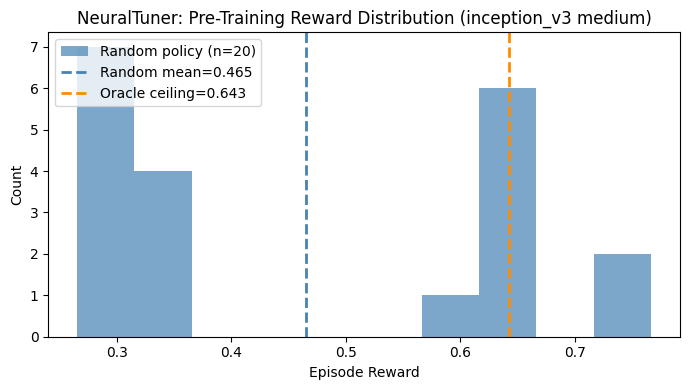

Saved: artifacts/plots/pre_training_reward_distribution.png


In [19]:
# True pre-training baseline: random dtype assignment, no profiling
random_rewards = []
for seed in range(20):
    m = run_random_episode(env, "inception_v3", "medium", seed=seed)
    random_rewards.append(m.final_reward)

random_mean = statistics.mean(random_rewards)
random_std = statistics.stdev(random_rewards)

# Reference upper ceiling (deterministic heuristic oracle)
oracle = run_heuristic_episode(env, "inception_v3", "medium")
print_pre_training_stats(random_mean, random_std, random_rewards, oracle)
plot_pre_training_reward_distribution(random_rewards, random_mean, oracle)


## 3) Qwen + TRL + OpenEnv GRPO pipeline

In [20]:
if _has_local_model_tensors(LOCAL_MODEL_DIR):
    print(f"Using cached model (no download): {LOCAL_MODEL_DIR}")
else:
    print(f"Cache incomplete. Downloading model to: {LOCAL_MODEL_DIR}")
    snapshot_download(
        repo_id=MODEL_REPO_ID,
        local_dir=str(LOCAL_MODEL_DIR),
        token=HF_TOKEN,
    )

MODEL_NAME = str(LOCAL_MODEL_DIR)
print(f"MODEL_FLAVOR selected: {MODEL_FLAVOR}")
print(f"MODEL_NAME set to local path: {MODEL_NAME}")

Cache incomplete. Downloading model to: /Users/altaf/code/round_2/.hf_cache/Qwen--Qwen2.5-0.5B-Instruct


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

MODEL_NAME set to local path: /Users/altaf/code/round_2/.hf_cache/Qwen--Qwen2.5-0.5B-Instruct


In [21]:
if not TARGET_LOCAL_MODEL_DIR.exists():
    raise FileNotFoundError(f"Expected local model cache missing: {TARGET_LOCAL_MODEL_DIR}")

processing_class = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, local_files_only=True)
processing_class.chat_template = qwen3_chat_template
processing_class.response_schema = qwen3_schema

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

mock_scenarios = _load_mock_scenarios(MOCK_DATA_PATH)
train_scenarios, eval_scenarios = split_scenarios(mock_scenarios, train_fraction=TRAIN_FRACTION, seed=SPLIT_SEED)
_DIFF_ORDER = {"easy": 0, "medium": 1, "hard": 2}
train_scenarios_curriculum = sorted(train_scenarios, key=lambda s: _DIFF_ORDER.get(s["difficulty"], 1))
counts = Counter(s["difficulty"] for s in train_scenarios_curriculum)
print(f"Curriculum: easy={counts['easy']}  medium={counts['medium']}  hard={counts['hard']}")
print(f"  Phase 1 (steps 1–{counts['easy']}): easy scenarios")
print(f"  Phase 2 (steps {counts['easy']+1}–{counts['easy']+counts['medium']}): medium")
print(f"  Phase 3 (steps {counts['easy']+counts['medium']+1}–{len(train_scenarios_curriculum)}): hard")

expanded_train = (train_scenarios_curriculum * ((TRAIN_EPISODES + len(train_scenarios_curriculum) - 1) // len(train_scenarios_curriculum)))[:TRAIN_EPISODES]
NeuralTunerOpenEnv.scenario_schedule = expanded_train
NeuralTunerOpenEnv.schedule_idx = 0

train_dataset = Dataset.from_dict(
    {
        "prompt": [_build_prompt_row(s) for s in expanded_train],
        "model_id": [s["model_id"] for s in expanded_train],
        "difficulty": [s["difficulty"] for s in expanded_train],
        "scenario_id": [s["id"] for s in expanded_train],
    }
)

# Held-out eval dataset — same schema as train_dataset.
# NeuralTunerOpenEnv.reset() uses model_id/difficulty kwargs directly when present,
# so these rows bypass the training scenario_schedule entirely.
eval_dataset = Dataset.from_dict(
    {
        "prompt": [_build_prompt_row(s) for s in eval_scenarios],
        "model_id": [s["model_id"] for s in eval_scenarios],
        "difficulty": [s["difficulty"] for s in eval_scenarios],
        "scenario_id": [s["id"] for s in eval_scenarios],
    }
)

print(f"train dataset:     {len(train_dataset)} episodes")
print(f"eval dataset:      {len(eval_dataset)} held-out episodes")
print(f"scenario split:    train={len(train_scenarios)} eval={len(eval_scenarios)}")
print(f"model:             {MODEL_NAME}")
print(f"mock source:       {MOCK_DATA_PATH}")
print("sample prompt:")
print(train_dataset[0]["prompt"][0]["content"][:500])

FileNotFoundError: Expected local model cache missing: /Users/altaf/code/round_2/Qwen/Qwen2.5-0.5B-Instruct

## 4) Save baseline
This saves baseline metrics and prompt data to trace what was used for training.

In [ ]:
artifacts_dir = Path("artifacts/training")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Baseline before training
baseline_env = NeuralTunerEnvironment()
baseline_metrics = run_baseline_episode(baseline_env, "inception_v3", "medium")
heuristic_metrics = run_heuristic_episode(baseline_env, "inception_v3", "medium")

baseline_path = artifacts_dir / "baseline_metrics.jsonl"
with baseline_path.open("w") as fp:
    fp.write(json.dumps(asdict(baseline_metrics)) + "\n")
    fp.write(json.dumps(asdict(heuristic_metrics)) + "\n")

prompts_path = artifacts_dir / "train_prompts.jsonl"
with prompts_path.open("w") as fp:
    for row in train_dataset:
        fp.write(json.dumps(row) + "\n")

print("Baseline metrics:")
print(asdict(baseline_metrics))
print(asdict(heuristic_metrics))
print(f"Saved baseline file: {baseline_path}")
print(f"Saved prompts file: {prompts_path}")


Baseline metrics:
{'policy': 'baseline', 'episode_index': 0, 'model_id': 'inception_v3', 'difficulty': 'medium', 'final_reward': 0.786, 'done': True, 'step_count': 10, 'benchmark_count': 1, 'latency_ms': 64.18, 'memory_mb': 40.01, 'accuracy_retention': 0.9663, 'constraints_met': True}
{'policy': 'heuristic', 'episode_index': 0, 'model_id': 'inception_v3', 'difficulty': 'medium', 'final_reward': 0.6428, 'done': True, 'step_count': 14, 'benchmark_count': 1, 'latency_ms': 93.77, 'memory_mb': 77.11, 'accuracy_retention': 0.9785, 'constraints_met': False}
Saved baseline file: artifacts/training/baseline_metrics.jsonl
Saved prompts file: artifacts/training/train_prompts.jsonl


## 5) Train  GRPO run, save checkpoint, print training results

In [ ]:
selected_device = RUNTIME_DEVICE
print(f"Selected runtime device: {selected_device}")

# Lightweight smoke check: ensure tokenized inputs can be moved to runtime device.
smoke_tokens = processing_class("device smoke check", return_tensors="pt")
smoke_tokens = {k: v.to(selected_device) for k, v in smoke_tokens.items()}
print(f"Smoke input_ids device: {smoke_tokens['input_ids'].device}")

Selected runtime device: mps
Smoke input_ids device: mps:0


In [ ]:
# SFT warm-up: teach the model the <tool_call> format before GRPO.
# Without this, the model emits empty completions → autosubmit fires → no useful reward signal.
print("Building SFT warm-up dataset from heuristic trajectories...")
sft_dataset = _build_sft_dataset(train_scenarios_curriculum)
print(f"SFT warm-up dataset: {len(sft_dataset)} examples")
print("Sample completion:")
print(sft_dataset[0]["messages"][-1]["content"][:300])

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    run_name="neural_tuner_sft_warmup",
    max_steps=SFT_WARMUP_STEPS,
    learning_rate=5e-5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    max_length=1024,
    gradient_checkpointing=True,
    logging_steps=1,
    save_steps=SFT_WARMUP_STEPS,
    save_total_limit=1,
    report_to="wandb" if WANDB_API_KEY else "none",
    use_cpu=USE_CPU,
    bf16=False,
    fp16=(RUNTIME_DEVICE in {"cuda", "mps"})
)

sft_trainer = SFTTrainer(
    model=MODEL_NAME,
    train_dataset=sft_dataset,
    args=sft_config,
    processing_class=processing_class,
    peft_config=peft_config,
)

print(f"Running SFT warm-up for {SFT_WARMUP_STEPS} steps...")
sft_trainer.train()
sft_trainer.save_model(OUTPUT_DIR)
print("SFT warm-up complete — model saved, starting GRPO.")

del sft_trainer
if RUNTIME_DEVICE == "mps":
    torch.mps.empty_cache()
elif RUNTIME_DEVICE == "cuda":
    torch.cuda.empty_cache()
gc.collect()

Building SFT warm-up dataset from heuristic trajectories...
SFT warm-up dataset: 95 examples
Sample completion:
<tool_call>{"name": "benchmark", "arguments": {}}</tool_call>
<tool_call>{"name": "submit", "arguments": {}}</tool_call>


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/95 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Running SFT warm-up for 20 steps...


/Users/altaf/code/round_2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
1,3.390085
2,3.224559
3,3.232243
4,2.972184
5,3.130213
6,3.032429
7,2.932354
8,2.932504
9,2.905505
10,2.671353


SFT warm-up complete — model saved, starting GRPO.


35060

In [ ]:
from transformers import TrainerCallback

class NeuralTunerEvalCallback(TrainerCallback):
    """Prints a one-line eval summary per checkpoint and logs derived lift metrics to W&B.

    Hooks into on_log (not on_evaluate) because GRPOTrainer merges eval_reward into
    the logs dict inside its own log() override, which triggers on_log. By the time
    on_evaluate fires, eval_reward is no longer in the accessible dict.

    TRL's WandbCallback already sends eval/reward, eval/loss, eval/reward_std.
    This callback adds only the two derived metrics TRL does not compute:
      - eval/lift_vs_random  (absolute gain above the pre-training random baseline)
      - eval/lift_vs_oracle  (fraction of the gap from random to oracle that is closed)
    """

    def __init__(self, random_mean: float, oracle_final_reward: float):
        self._random_mean = random_mean
        self._oracle_reward = oracle_final_reward

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        eval_reward = logs.get("eval_reward")
        if eval_reward is None:
            return  # training log event — skip

        step = state.global_step
        lift_vs_random = eval_reward - self._random_mean
        oracle_range = self._oracle_reward - self._random_mean
        lift_vs_oracle = (lift_vs_random / oracle_range) if abs(oracle_range) > 1e-6 else 0.0

        reward_std = logs.get("eval_reward_std", float("nan"))
        eval_loss = logs.get("eval_loss")
        loss_str = f"  eval_loss={eval_loss:.4f}" if eval_loss is not None else ""

        print(
            f"[eval step={step}]  reward={eval_reward:.4f} ± {reward_std:.4f}"
            f"  lift_vs_random={lift_vs_random:+.4f}"
            f"  lift_vs_oracle={lift_vs_oracle:.2%}"
            f"{loss_str}"
        )

        try:
            import wandb as _wandb
            if _wandb.run is not None:
                # Do NOT pass step= here — WandbCallback already advanced W&B's step counter.
                _wandb.log({
                    "eval/lift_vs_random": lift_vs_random,
                    "eval/lift_vs_oracle": lift_vs_oracle,
                })
        except Exception:
            pass  # degrade gracefully if wandb is inactive


class CollapseGuardCallback(TrainerCallback):
    """Early-stop guard for persistent GRPO signal collapse."""

    def __init__(self, window: int = 5, max_zero_std_windows: int = 3, min_entropy: float = 0.05):
        self.window = window
        self.max_zero_std_windows = max_zero_std_windows
        self.min_entropy = min_entropy
        self._recent_zero_std = []
        self._recent_entropy = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return

        frac_zero_std = logs.get("frac_reward_zero_std")
        entropy = logs.get("entropy")
        reward_std = logs.get("reward_std")

        if frac_zero_std is not None:
            self._recent_zero_std.append(float(frac_zero_std))
            self._recent_zero_std = self._recent_zero_std[-self.window :]
        if entropy is not None:
            self._recent_entropy.append(float(entropy))
            self._recent_entropy = self._recent_entropy[-self.window :]

        if len(self._recent_zero_std) < self.window or len(self._recent_entropy) < self.window:
            return

        zero_std_windows = sum(1 for x in self._recent_zero_std if x >= 0.95)
        mean_entropy = sum(self._recent_entropy) / len(self._recent_entropy)

        if zero_std_windows >= self.max_zero_std_windows and mean_entropy <= self.min_entropy:
            print(
                "[collapse-guard] triggered at step="
                f"{state.global_step}: reward_std={reward_std}, "
                f"zero_std_windows={zero_std_windows}/{self.window}, "
                f"mean_entropy={mean_entropy:.4f}. Stopping training early."
            )
            control.should_training_stop = True


In [ ]:
grpo_config = GRPOConfig(
    output_dir=OUTPUT_DIR,
    run_name="neural_tuner_grpo",
    num_iterations=NUM_EPOCHS,
    max_steps=NUM_STEPS,
    learning_rate=8e-7,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    warmup_steps=2,
    max_completion_length=192,
    num_generations=6,
    generation_batch_size=6,
    temperature=0.9,
    top_p=0.95,
    generation_kwargs={"do_sample": True, "renormalize_logits": True, "remove_invalid_values": True},
    mask_truncated_completions=False,
    max_tool_calling_iterations=20,
    log_completions=False,
    num_completions_to_print=None,
    gradient_checkpointing=True,
    torch_empty_cache_steps=1,
    logging_steps=1,
    save_steps=20,
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=10,
    per_device_eval_batch_size=6,
    num_generations_eval=6,
    report_to="wandb" if WANDB_API_KEY else "none",
    use_cpu=USE_CPU,
    bf16=False,
    fp16=True,
    use_vllm=False,
)

In [ ]:
from peft import PeftModel
from transformers import AutoModelForCausalLM

if RUNTIME_DEVICE == "mps":
    torch.mps.empty_cache()
elif RUNTIME_DEVICE == "cuda":
    torch.cuda.empty_cache()
gc.collect()

# Load base model + SFT-warmed LoRA adapter so GRPO continues from the warm checkpoint.
# GRPOTrainer can't load a LoRA-only directory via string path — pass a PeftModel object instead.
_base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16)
sft_warmed_model = PeftModel.from_pretrained(_base_model, OUTPUT_DIR, is_trainable=True)

trainer = GRPOTrainer(
    model=sft_warmed_model,
    reward_funcs=reward_func,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=grpo_config,
    processing_class=processing_class,
    peft_config=None,  # model already has LoRA from SFT warm-up
    environment_factory=NeuralTunerOpenEnv,
    callbacks=[
        NeuralTunerEvalCallback(
            random_mean=random_mean,
            oracle_final_reward=oracle.final_reward,
        ),
        CollapseGuardCallback(window=5, max_zero_std_windows=3, min_entropy=0.05),
    ],
)

print("[collapse-guard] active: window=5, max_zero_std_windows=3, min_entropy=0.05")
trainer_stats = trainer.train()
trainer.save_model(OUTPUT_DIR)

best_ckpt = getattr(trainer.state, "best_model_checkpoint", None)
print(f"Best checkpoint selected: {best_ckpt if best_ckpt else 'not set (single-run/no selection)'}")

metrics_path = Path("artifacts/training/train_metrics.json")
metrics_path.parent.mkdir(parents=True, exist_ok=True)
metrics_path.write_text(json.dumps(trainer_stats.metrics, indent=2))
post_training_comparison(trainer, random_mean, random_std, random_rewards, oracle, trainer_stats, metrics_path)
post_training_logs(trainer, random_mean, random_std, oracle, train_scenarios_curriculum, eval_scenarios)

if WANDB_API_KEY:
    wandb.finish()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/var/folders/s5/njr5fmg95_3b909cnj52vxq40000gn/T/ipykernel_97187/1504397404.py:15: UserWarning: You are using 'environment_factory', which is an experimental feature. This API may change or be removed at any time without prior notice. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  trainer = GRPOTrainer(
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


[collapse-guard] active: window=5, max_zero_std_windows=3, min_entropy=0.05


/Users/altaf/code/round_2/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss


ValueError: zip() argument 2 is longer than argument 1

: 

## 6) Post-training evaluation
Compare trained model performance against pre-training random baseline and oracle ceiling.

In [ ]:
post_training_logs(trainer,random_mean,random_std, oracle, train_scenarios, eval_scenarios)